# Plot figures for 2 new papers about the DM-z relation

Plot FRB DM-z relation for two recently paper:

[Surajit](https://ui.adsabs.harvard.edu/abs/2024arXiv241001974K/abstract)

[Kritti](https://ui.adsabs.harvard.edu/abs/2024arXiv240916964S/abstract)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import astropy.units as astu
import astropy.constants as const
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import z_at_value
from astropy.cosmology import Planck18
from scipy import stats

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df1 = pd.read_csv('../data/FRB_Surajit.csv')
df1.head()

,FRB,DM_obs (pc cm^-3),E_DM_obs,DM_MW (pc cm^-3),z,DM_ext
0,FRB 20121102A,557.00,2.00,188.0,0.19273,369.00
1,FRB 20171020A,114.10,0.20,38.0,0.00860,76.10
2,FRB 20180301A,522.00,0.20,152.0,0.33040,370.00
3,FRB 20180916B,349.30,0.20,200.0,0.03370,149.30
4,FRB 20180924B,361.42,0.06,40.5,0.32140,320.92


In [3]:
fit1=np.polyfit(df1['z'], df1['DM_ext'],1)
slope1, intercept1 = fit1
print(slope1, intercept1)

992.2797150459426 145.06779226189732


In [4]:
df2 = pd.read_excel('../data/FRB_Kritti.xlsx')
df2.head()

,FRB,z,DM_ext,Voltage localization,"host_loc (deg, deg)","host_loc (hms, dms)"
0,FRB 20220204A,0.4012,559.43,18h16m54.30s +69d43m21.01s,"274.2278, 69.7222","18:16:54.67, +69:43:19.92"
1,FRB 20220207C,0.0433,182.98,20h40m47.886s +72d52m56.378s,"310.197579, +72.882749","20:40:47.4189, +72:52:57.897"
2,FRB 20220208A,0.3510,346.65,21h30m18.03s +70d02m27.75s,"322.572, 70.042","21:30:17.28, 70:02:31.20"
3,FRB 20220307B,0.2481,363.43,23h23m29.879s +72d11m32.59s,"350.8747, 72.1919","23:23:29.9248, +72:11:30.803"
4,FRB 20220310F,0.4780,416.71,08h58m52.92s +73d29m27.0s,"134.721078150, 73.491016090","8:58:53.0539, +73:29:27.445"


In [5]:
df2['FRB']='FRB '+df2['FRB']
df2.head()

,FRB,z,DM_ext,Voltage localization,"host_loc (deg, deg)","host_loc (hms, dms)"
0,FRB FRB 20220204A,0.4012,559.43,18h16m54.30s +69d43m21.01s,"274.2278, 69.7222","18:16:54.67, +69:43:19.92"
1,FRB FRB 20220207C,0.0433,182.98,20h40m47.886s +72d52m56.378s,"310.197579, +72.882749","20:40:47.4189, +72:52:57.897"
2,FRB FRB 20220208A,0.3510,346.65,21h30m18.03s +70d02m27.75s,"322.572, 70.042","21:30:17.28, 70:02:31.20"
3,FRB FRB 20220307B,0.2481,363.43,23h23m29.879s +72d11m32.59s,"350.8747, 72.1919","23:23:29.9248, +72:11:30.803"
4,FRB FRB 20220310F,0.4780,416.71,08h58m52.92s +73d29m27.0s,"134.721078150, 73.491016090","8:58:53.0539, +73:29:27.445"


In [6]:
fit2=np.polyfit(df2.loc[:,'z'], df2.loc[:,'DM_ext'],1)
slope2, intercept2 = fit2
print(slope2, intercept2)

882.7960525316848 184.187514943296


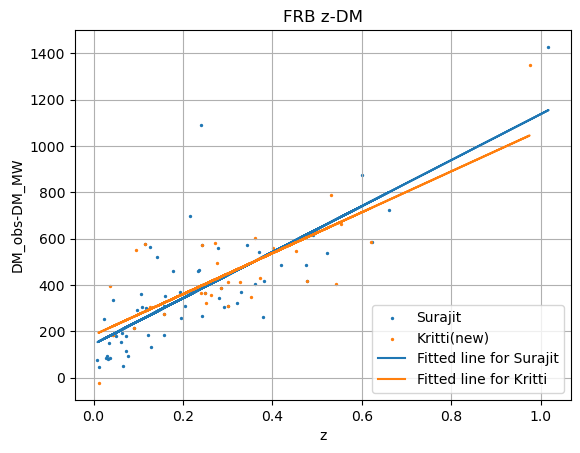

In [7]:
plt.scatter(df1['z'], df1['DM_ext'], label='Surajit',s=2)
plt.scatter(df2['z'], df2['DM_ext'], label='Kritti(new)',s=2)
#plt.errorbar(df2['z'], df2['DM_ext'], xerr=df2['E_z'], fmt='o', ecolor='red', capsize=1, label='Kritti(new)',markersize=2)
plt.plot(df1['z'],slope1*df1['z']+intercept1, label='Fitted line for Surajit')
plt.plot(df2['z'],slope2*df2['z']+intercept2, label='Fitted line for Kritti')
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.legend()
plt.grid(True)
plt.show()

# Data pre-processing and visualization

In [8]:
df=pd.read_excel("../data/FRB_all.xlsx")
df=df[['FRB','z','DM_ext']]
df.head()

,FRB,z,DM_ext
0,FRB 20220204A,0.4012,559.43
1,FRB 20220207C,0.0433,182.98
2,FRB 20220208A,0.3510,346.65
3,FRB 20220307B,0.2481,363.43
4,FRB 20220310F,0.4780,416.71


In [9]:
fit=np.polyfit(df['z'], df['DM_ext'],1)
slope, intercept = fit
print(slope, intercept)

989.5927354610134 151.3101576011383


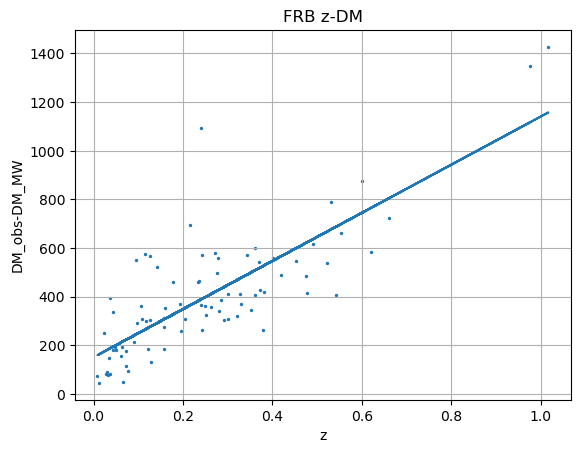

In [10]:
plt.scatter(df['z'], df['DM_ext'],s=2)
plt.plot(df['z'],slope*df['z']+intercept)
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Linear Regression (99% Confidence Interval)')

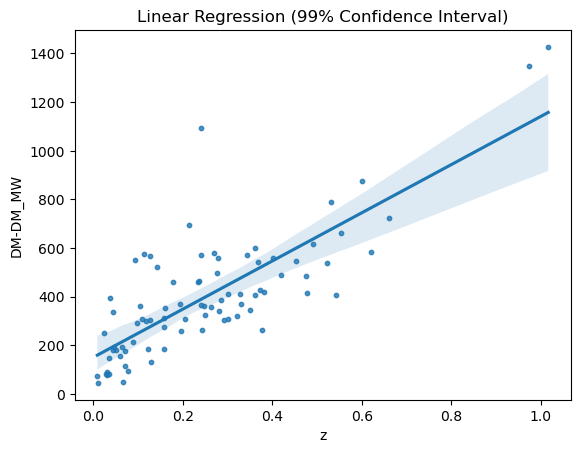

In [11]:
sns.regplot(data=df, x="z",y="DM_ext",ci=99,scatter_kws={"s":10})
plt.ylabel('DM-DM_MW')
plt.title('Linear Regression (99% Confidence Interval)')

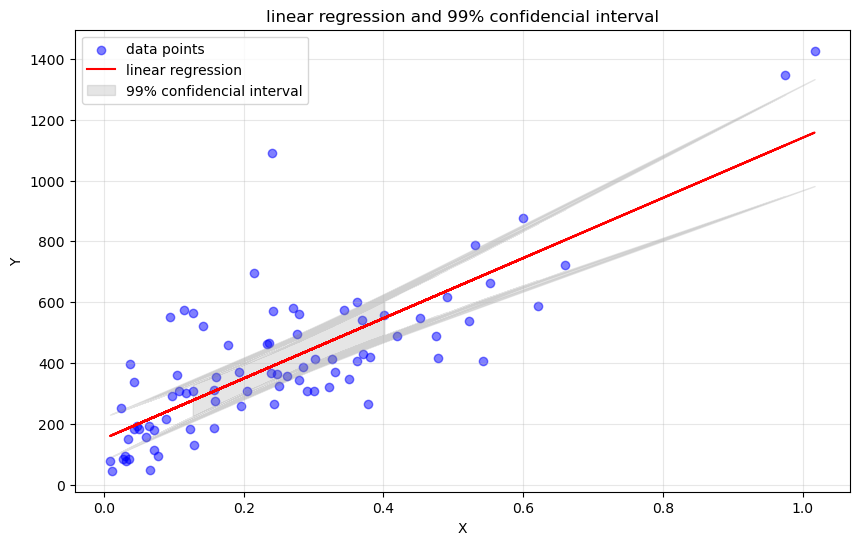

slope: 989.5927
intercept: 151.3102
R²: 0.6299
p: 0.0000


In [12]:
x=df['z']
y=df['DM_ext']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

y_pred = slope * x + intercept

def confidence_interval(x, y, y_pred, confidence=0.99):
    n = len(x)
    mean_x = np.mean(x)
    
    sum_sq = np.sum((y - y_pred) ** 2)
    std_err = np.sqrt(sum_sq / (n-2))
    
    x_new = np.column_stack([np.ones(len(x)), x])
    mse = sum_sq / (n - 2)
    var_b = mse * np.linalg.inv(np.dot(x_new.T, x_new))
    
    std_fit = np.sqrt(np.diagonal(np.dot(x_new, np.dot(var_b, x_new.T))))
    
    t = stats.t.ppf((1 + confidence) / 2, n - 2)
    ci = t * std_fit
    
    return ci

ci = confidence_interval(x, y, y_pred)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.5, label='data points')
plt.plot(x, y_pred, color='red', label='linear regression')
plt.fill_between(x, y_pred - ci, y_pred + ci, color='gray', alpha=0.2, label='99% confidencial interval')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('linear regression and 99% confidencial interval')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"slope: {slope:.4f}")
print(f"intercept: {intercept:.4f}")
print(f"R²: {r_value**2:.4f}")
print(f"p: {p_value:.4f}")

DM_MW, halo

In [13]:
DM_halo=50
df['DM_ext']=df['DM_ext']-DM_halo
df.head()

,FRB,z,DM_ext
0,FRB 20220204A,0.4012,509.43
1,FRB 20220207C,0.0433,132.98
2,FRB 20220208A,0.3510,296.65
3,FRB 20220307B,0.2481,313.43
4,FRB 20220310F,0.4780,366.71


Drop FRB 20190520B

In [14]:
print(len(df))
df = df[df['FRB'] != 'FRB 20190520B']
print(len(df))
df.head()

83
82


,FRB,z,DM_ext
0,FRB 20220204A,0.4012,509.43
1,FRB 20220207C,0.0433,132.98
2,FRB 20220208A,0.3510,296.65
3,FRB 20220307B,0.2481,313.43
4,FRB 20220310F,0.4780,366.71


In [15]:
# Assuming your dataframe is named df
# 1. Find rows where DM_ext < 0
dropped_rows = df[df['DM_ext'] < 0]

# 2. Print FRB values of dropped rows if any exist
if not dropped_rows.empty:
    print("Dropped rows:")
    print(dropped_rows[['FRB', 'DM_ext']])
else:
    print("No rows with DM_ext < 0 found to drop")

# 3. Keep only rows where DM_ext >= 0
df = df[df['DM_ext'] >= 0]

print(f'Now there are {len(df)} rows in the dataframe')

Dropped rows:
              FRB  DM_ext
5   FRB 20220319D   -4.30
60  FRB 20210405I   -0.93
Now there are 80 rows in the dataframe


In [16]:
df['DM_ext'] = df['DM_ext'].round(2)
df.to_csv("../data/FRB.csv",index=None)

# Macquart result

In [17]:
Mac_frbs=['FRB 20180924B','FRB 20181112A','FRB 20190102C','FRB 20190608B','FRB 20190711A']

In [18]:
df_mac= df[df['FRB'].isin(Mac_frbs)]
df_mac

,FRB,z,DM_ext
34,FRB 20180924B,0.3214,270.92
35,FRB 20181112A,0.4755,437.27
38,FRB 20190102C,0.2910,256.30
45,FRB 20190608B,0.1178,251.50
48,FRB 20190711A,0.5220,486.70


Text(0.5, 1.0, 'Linear Regression (90% Confidence Interval)')

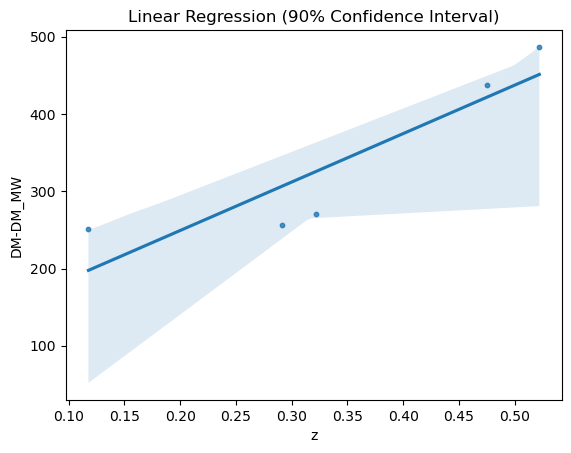

In [19]:
sns.regplot(data=df_mac, x="z",y="DM_ext",ci=90,scatter_kws={"s":10})
plt.ylabel('DM-DM_MW')
plt.title('Linear Regression (90% Confidence Interval)')

In [20]:
df_mac.to_csv("../data/FRB_Macquart.csv",index=None)